In [4]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/ealtman2019/ibm-transactions-for-anti-money-laundering-aml/HI-Medium_accounts.csv
/kaggle/input/datasets/ealtman2019/ibm-transactions-for-anti-money-laundering-aml/LI-Small_Trans.csv
/kaggle/input/datasets/ealtman2019/ibm-transactions-for-anti-money-laundering-aml/HI-Large_accounts.csv
/kaggle/input/datasets/ealtman2019/ibm-transactions-for-anti-money-laundering-aml/HI-Large_Trans.csv
/kaggle/input/datasets/ealtman2019/ibm-transactions-for-anti-money-laundering-aml/HI-Medium_Trans.csv
/kaggle/input/datasets/ealtman2019/ibm-transactions-for-anti-money-laundering-aml/LI-Medium_accounts.csv
/kaggle/input/datasets/ealtman2019/ibm-transactions-for-anti-money-laundering-aml/HI-Small_Patterns.txt
/kaggle/input/datasets/ealtman2019/ibm-transactions-for-anti-money-laundering-aml/HI-Medium_Patterns.txt
/kaggle/input/datasets/ealtman2019/ibm-transactions-for-anti-money-laundering-aml/HI-Small_accounts.csv
/kaggle/input/datasets/ealtman2019/ibm-transactions-for-anti-money-la

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn as sk
import seaborn as sns

d1 = pd.read_csv("/kaggle/input/datasets/ealtman2019/ibm-transactions-for-anti-money-laundering-aml/LI-Small_accounts.csv")
d2 = pd.read_csv("/kaggle/input/datasets/ealtman2019/ibm-transactions-for-anti-money-laundering-aml/LI-Small_Trans.csv")


#mule accounts eda
#

In [7]:
print(d2.head())
#sorting the transactions wrt date and time

          Timestamp  From Bank    Account  To Bank  Account.1  \
0  2022/09/01 00:08         11  8000ECA90       11  8000ECA90   
1  2022/09/01 00:21       3402  80021DAD0     3402  80021DAD0   
2  2022/09/01 00:00         11  8000ECA90     1120  8006AA910   
3  2022/09/01 00:16       3814  8006AD080     3814  8006AD080   
4  2022/09/01 00:00         20  8006AD530       20  8006AD530   

   Amount Received Receiving Currency  Amount Paid Payment Currency  \
0       3195403.00          US Dollar   3195403.00        US Dollar   
1          1858.96          US Dollar      1858.96        US Dollar   
2        592571.00          US Dollar    592571.00        US Dollar   
3            12.32          US Dollar        12.32        US Dollar   
4          2941.56          US Dollar      2941.56        US Dollar   

  Payment Format  Is Laundering  
0   Reinvestment              0  
1   Reinvestment              0  
2         Cheque              0  
3   Reinvestment              0  
4   Reinvest

In [8]:
trans = d2.copy()
acc = d1.copy()
x = trans.copy()
d2.head()


,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering
0,2022/09/01 00:08,11,8000ECA90,11,8000ECA90,3195403.00,US Dollar,3195403.00,US Dollar,Reinvestment,0
1,2022/09/01 00:21,3402,80021DAD0,3402,80021DAD0,1858.96,US Dollar,1858.96,US Dollar,Reinvestment,0
2,2022/09/01 00:00,11,8000ECA90,1120,8006AA910,592571.00,US Dollar,592571.00,US Dollar,Cheque,0
3,2022/09/01 00:16,3814,8006AD080,3814,8006AD080,12.32,US Dollar,12.32,US Dollar,Reinvestment,0
4,2022/09/01 00:00,20,8006AD530,20,8006AD530,2941.56,US Dollar,2941.56,US Dollar,Reinvestment,0


In [9]:
# 1. Ensure it is datetime format first
x['Timestamp'] = pd.to_datetime(x['Timestamp'], format='%Y/%m/%d %H:%M')

# 2. Extract components
x['hour'] = x['Timestamp'].dt.hour
x['minute'] = x['Timestamp'].dt.minute
# 3. Create the Date only column (YYYY-MM-DD)
x['Date'] = x['Timestamp'].dt.date

# 4. Remove the original Timestamp column so it doesn't cause errors later
x = x.drop(columns=['Timestamp'])

print(x[['Date', 'hour', 'minute']].head())

         Date  hour  minute
0  2022-09-01     0       8
1  2022-09-01     0      21
2  2022-09-01     0       0
3  2022-09-01     0      16
4  2022-09-01     0       0


In [10]:
# Sort by the timeline hierarchy
# We use reset_index(drop=True) so the row numbers follow the new order
x = x.sort_values(by=['Date', 'hour', 'minute']).reset_index(drop=True)

# Verify the first 10 rows to see the progression
print(x[['Date', 'hour', 'minute']].head(10))

         Date  hour  minute
0  2022-09-01     0       0
1  2022-09-01     0       0
2  2022-09-01     0       0
3  2022-09-01     0       0
4  2022-09-01     0       0
5  2022-09-01     0       0
6  2022-09-01     0       0
7  2022-09-01     0       0
8  2022-09-01     0       0
9  2022-09-01     0       0


In [11]:
# Now that timeline is sorted, data leakage is out of question and we can go ahead with splitting the data set into train,validation and test set
# 1. Calculate the split indexes
n = len(x)
train_idx = int(n * 0.6)
val_idx = int(n * 0.8)

# 2. Slice into three completely isolated sets
train_df = x.iloc[:train_idx].copy()
val_df = x.iloc[train_idx:val_idx].copy()
test_df = x.iloc[val_idx:].copy()

print(f"Train: {len(train_df)} rows")
print(f"Val: {len(val_df)} rows")
print(f"Test: {len(test_df)} rows")
# Reset indexes so each dataframe starts at 0
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

Train: 4154429 rows
Val: 1384810 rows
Test: 1384810 rows


In [12]:
df = train_df.copy()
df.head(-10)

,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering,hour,minute,Date
0,11,8000ECA90,1120,8006AA910,592571.00,US Dollar,592571.00,US Dollar,Cheque,0,0,0,2022-09-01
1,20,8006AD530,20,8006AD530,2941.56,US Dollar,2941.56,US Dollar,Reinvestment,0,0,0,2022-09-01
2,1120,800BC4DC0,37146,80FE04360,0.36,US Dollar,0.36,US Dollar,Credit Card,0,0,0,2022-09-01
3,531,800F70C00,1291,800F73990,4341.99,US Dollar,4341.99,US Dollar,Cheque,0,0,0,2022-09-01
4,1889,800F77250,11968,80CB23DC0,140.68,US Dollar,140.68,US Dollar,Credit Card,0,0,0,2022-09-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4154414,1889,80100F490,394,801251E90,783.05,US Dollar,783.05,US Dollar,ACH,0,13,32,2022-09-06
4154415,20,8004EC010,3718,801787AC0,25926.97,US Dollar,25926.97,US Dollar,Cheque,0,13,32,2022-09-06
4154416,20,8004EC010,3718,801787AC0,36612.18,US Dollar,36612.18,US Dollar,ACH,0,13,32,2022-09-06
4154417,20,800044900,11,8018B6AE0,9120.98,US Dollar,9120.98,US Dollar,Credit Card,0,13,32,2022-09-06


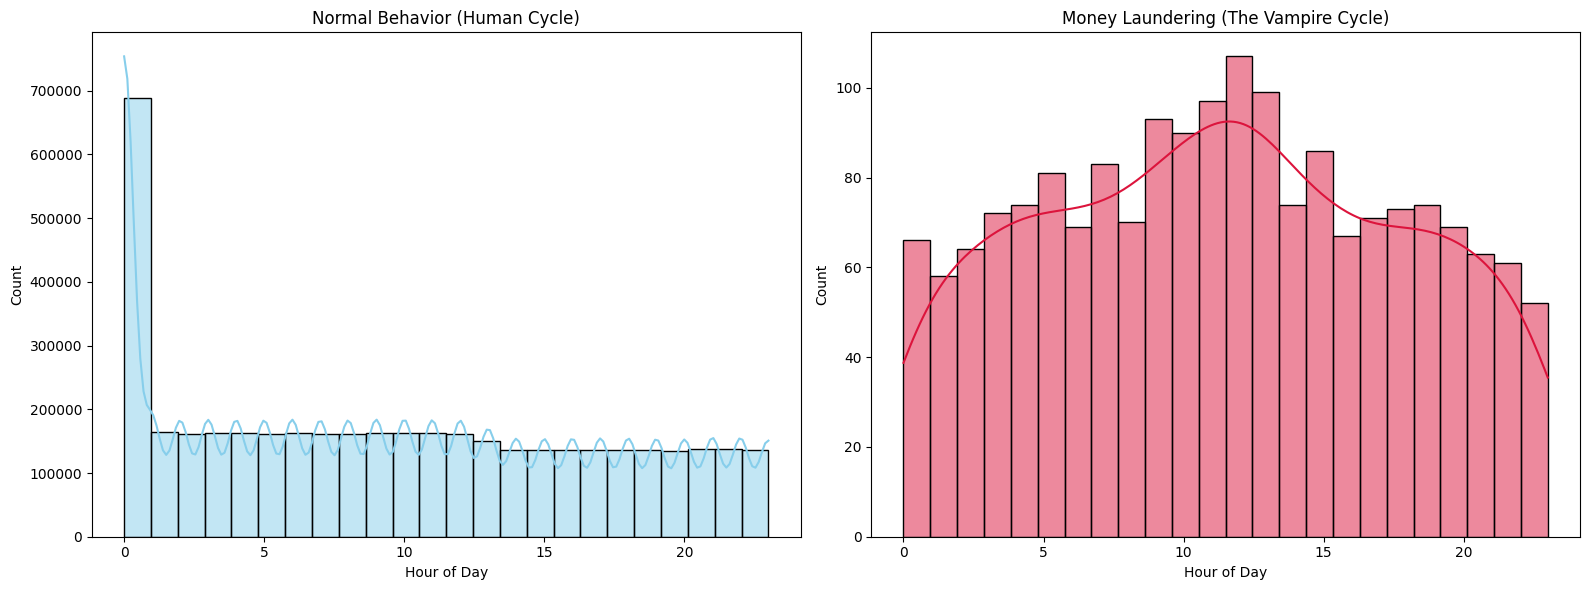

In [13]:
# EDA
#1) First let us only analyze the accounts that have laundered money
# Creating two dataframes for comparison
fraud = df[df['Is Laundering'] == 1]
normal = df[df['Is Laundering'] == 0]

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Legitimate Transactions (The Baseline)
sns.histplot(normal['hour'], bins=24, color='skyblue', kde=True, ax=ax[0])
ax[0].set_title('Normal Behavior (Human Cycle)')
ax[0].set_xlabel('Hour of Day')

# Plot 2: Fraudulent Transactions (The Signal)
sns.histplot(fraud['hour'], bins=24, color='crimson', kde=True, ax=ax[1])
ax[1].set_title('Money Laundering (The Vampire Cycle)')
ax[1].set_xlabel('Hour of Day')

plt.tight_layout()
plt.show()

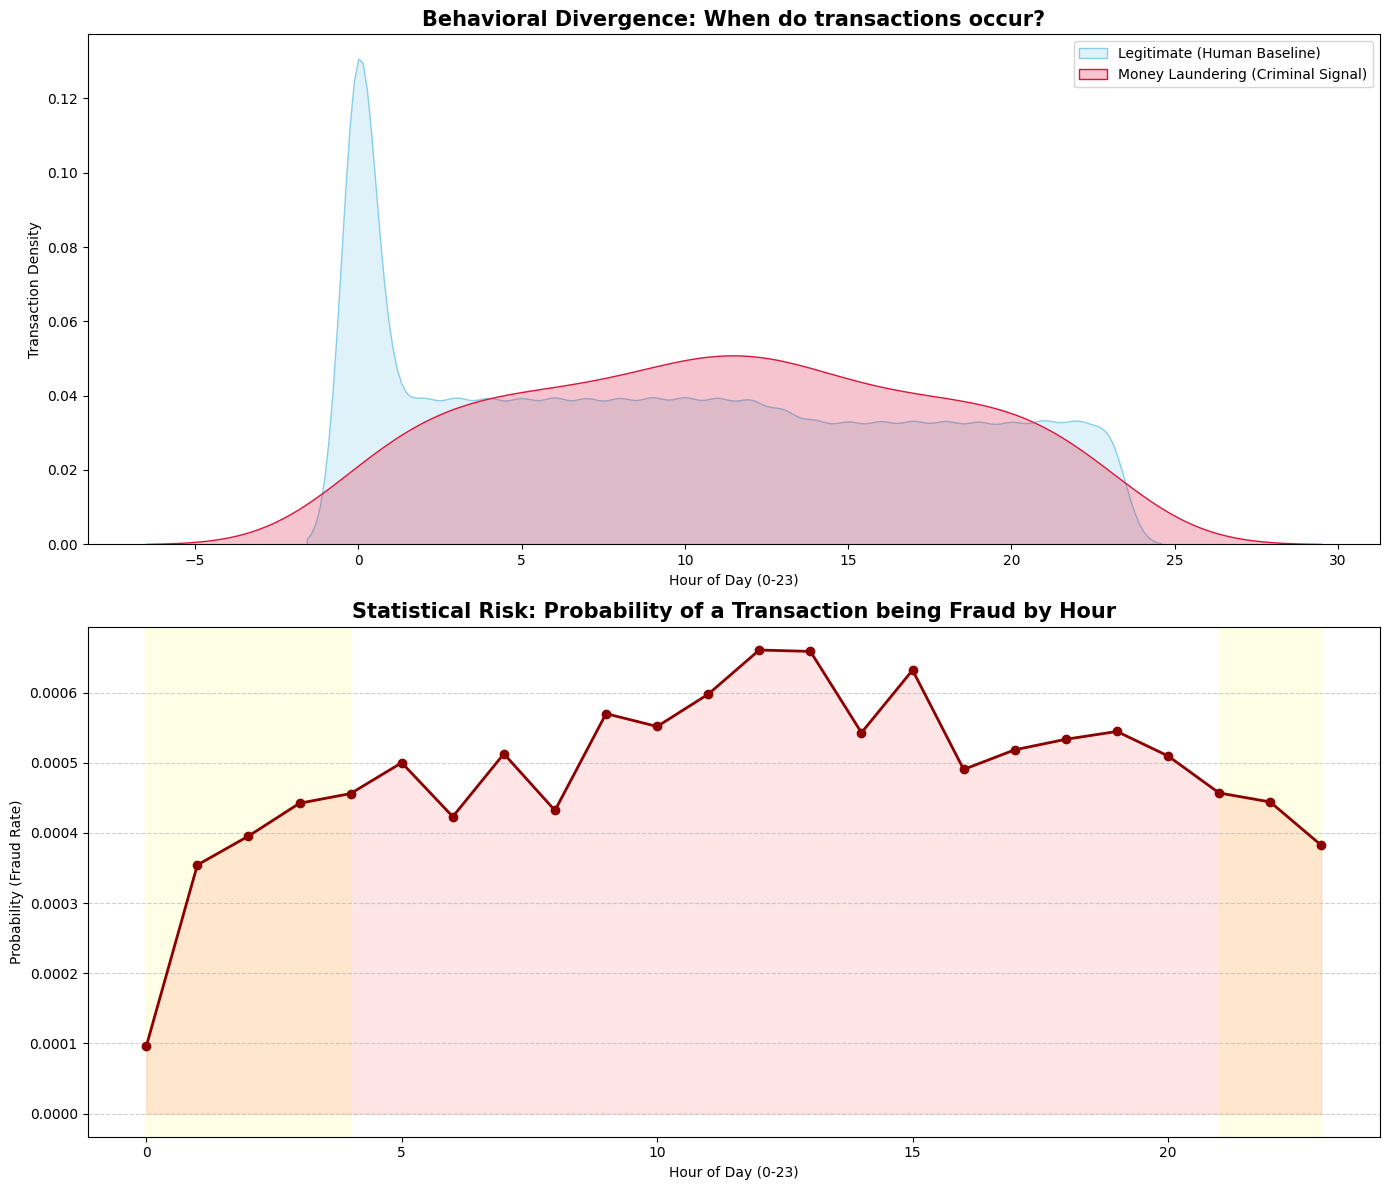

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Calculating the Statistical Risk (Probability of Fraud per Hour)
# This is P(Fraud | Hour), conditional probability that means "Given a transaction happened at a certain hour, what is the probability that it is fraud?”
fraud_prob = train_df.groupby('hour')['Is Laundering'].mean()
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12))

# PLOT 1: Comparing Distributions (Where is the volume?)
sns.kdeplot(df[df['Is Laundering'] == 0]['hour'], 
            label='Legitimate (Human Baseline)', fill=True, color='skyblue', ax=ax1, bw_adjust=1.5)
sns.kdeplot(df[df['Is Laundering'] == 1]['hour'], 
            label='Money Laundering (Criminal Signal)', fill=True, color='crimson', ax=ax1, bw_adjust=1.5)

ax1.set_title('Behavioral Divergence: When do transactions occur?', fontsize=15, fontweight='bold')
ax1.set_xlabel('Hour of Day (0-23)')
ax1.set_ylabel('Transaction Density')
ax1.legend()

# PLOT 2: Statistical Risk (The Probability Line)
ax2.plot(fraud_prob.index, fraud_prob.values, marker='o', linestyle='-', color='darkred', linewidth=2)
ax2.fill_between(fraud_prob.index, fraud_prob.values, color='red', alpha=0.1)

ax2.set_title('Statistical Risk: Probability of a Transaction being Fraud by Hour', fontsize=15, fontweight='bold')
ax2.set_xlabel('Hour of Day (0-23)')
ax2.set_ylabel('Probability (Fraud Rate)')
ax2.grid(axis='y', linestyle='--', alpha=0.6)

# Highlight the "Night-Time Risk Zone" (e.g., 10 PM to 4 AM)
ax2.axvspan(0, 4, color='yellow', alpha=0.1, label='High Risk Window')
ax2.axvspan(21, 23, color='yellow', alpha=0.1)

plt.tight_layout()
plt.show()

In [15]:
'''
Usually, you'd expect criminals to move money at 3:00 AM when the world is asleep.
But in this specific banking environment generated using IBM AML simulator
the 'Legitimate' traffic actually has a massive, automated spike at exactly Midnight—likely due to scheduled bill payments and bank maintenance or some other reason.
The money launderers seem to know this.
Instead of hiding in the dark, they are hiding in the daylight.
We can see they move money during business hours to 'blend in' with the messy, diverse flow of human transactions
rather than getting caught in the highly predictable window at midnight.
These criminals mimic human daytime behavior to bypass filters that are designed to flag these payments in off-hours.

'''

"\nUsually, you'd expect criminals to move money at 3:00 AM when the world is asleep.\nBut in this specific banking environment generated using IBM AML simulator\nthe 'Legitimate' traffic actually has a massive, automated spike at exactly Midnight—likely due to scheduled bill payments and bank maintenance or some other reason.\nThe money launderers seem to know this.\nInstead of hiding in the dark, they are hiding in the daylight.\nWe can see they move money during business hours to 'blend in' with the messy, diverse flow of human transactions\nrather than getting caught in the highly predictable window at midnight.\nThese criminals mimic human daytime behavior to bypass filters that are designed to flag these payments in off-hours.\n\n"

/tmp/ipykernel_1691/1753972506.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  amount_risk = x3.groupby('amount_bucket')['Is Laundering'].mean()


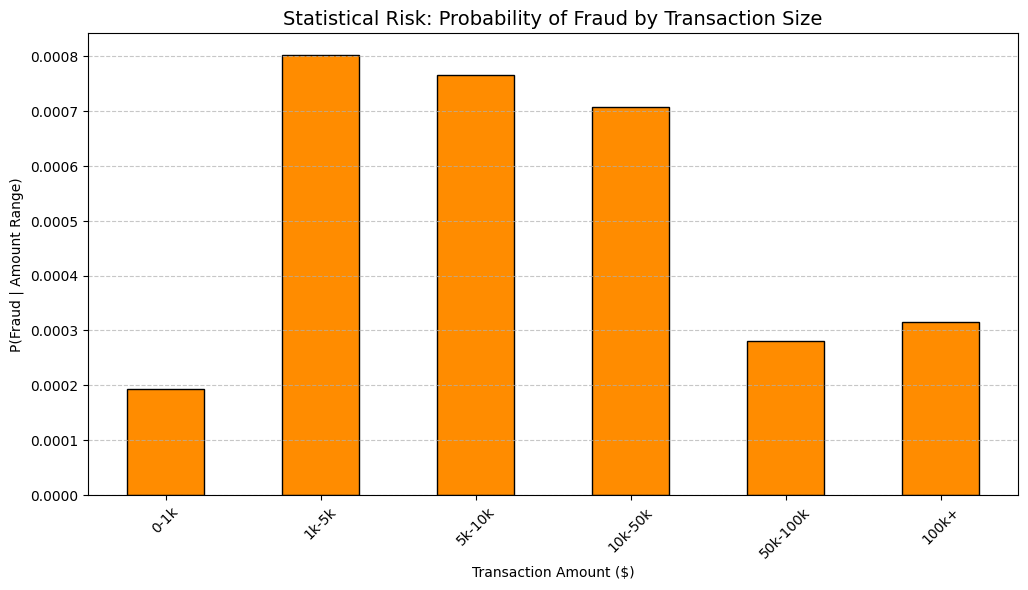

In [16]:
# 3. Create custom bins to catch the 'Reporting Thresholds'
#Fraud often behaves differently across transaction sizes.
x3 = df.copy()
bins = [0, 1000, 5000, 10000, 50000, 100000, df['Amount Paid'].max()]
labels = ['0-1k', '1k-5k', '5k-10k', '10k-50k', '50k-100k', '100k+']

x3['amount_bucket'] = pd.cut(df['Amount Paid'], bins=bins, labels=labels)

# 2. Calculate the Statistical Risk (Probability)
amount_risk = x3.groupby('amount_bucket')['Is Laundering'].mean()

# 3. Plot it
plt.figure(figsize=(12,6))
amount_risk.plot(kind='bar', color='darkorange', edgecolor='black')
plt.title('Statistical Risk: Probability of Fraud by Transaction Size', fontsize=14)
plt.ylabel('P(Fraud | Amount Range)')
plt.xlabel('Transaction Amount ($)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

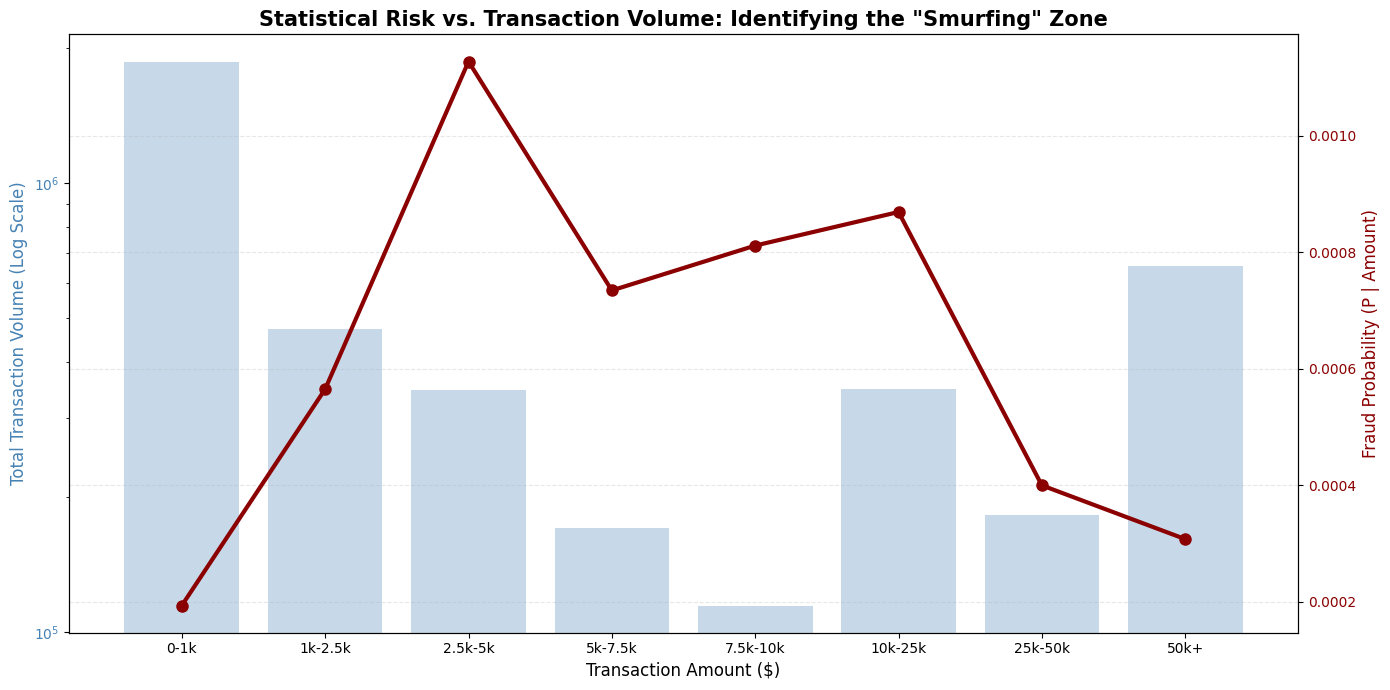

In [17]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Create a temporary local copy for the EDA task
# Using .copy() ensures that anything we do here stays in 'eda_temp'
eda_temp = df.iloc[:train_idx].copy() 

# 2. Define forensic bins (focused on catching the 'Smurfing' threshold)
bins = [0, 1000, 2500, 5000, 7500, 10000, 25000, 50000, eda_temp['Amount Paid'].max()]
labels = ['0-1k', '1k-2.5k', '2.5k-5k', '5k-7.5k', '7.5k-10k', '10k-25k', '25k-50k', '50k+']

# Apply the bins to our copy
eda_temp['amount_bucket'] = pd.cut(eda_temp['Amount Paid'], bins=bins, labels=labels)

# 3. Calculate stats with the 'observed=False' fix to suppress warnings
stats = eda_temp.groupby('amount_bucket', observed=False)['Is Laundering'].agg(['mean', 'count'])
stats.columns = ['fraud_rate', 'total_txns']

# 4. Create the Visualization
fig, ax1 = plt.subplots(figsize=(14, 7))

# Plot Volume as Bars (using Log Scale for clarity)
ax1.bar(stats.index, stats['total_txns'], color='steelblue', alpha=0.3, label='Total Volume')
ax1.set_ylabel('Total Transaction Volume (Log Scale)', color='steelblue', fontsize=12)
ax1.set_yscale('log')
ax1.set_xlabel('Transaction Amount ($)', fontsize=12)
ax1.tick_params(axis='y', labelcolor='steelblue')

# Create a second axis for the Fraud Probability (The Risk Line)
ax2 = ax1.twinx() 
ax2.plot(stats.index, stats['fraud_rate'], color='darkred', marker='o', linewidth=3, markersize=8, label='Fraud Probability')
ax2.set_ylabel('Fraud Probability (P | Amount)', color='darkred', fontsize=12)
ax2.tick_params(axis='y', labelcolor='darkred')

plt.title('Statistical Risk vs. Transaction Volume: Identifying the "Smurfing" Zone', fontsize=15, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.3)
fig.tight_layout()
plt.show()

# The 'eda_temp' will be cleared from memory once you're done, leaving your original 'x' clean.

In [18]:
'''
Executive Summary: Why High-Value is a Low-Risk Signal
The dual-axis analysis reveals a sophisticated, non-linear relationship between transaction value and illicit risk. Contrary to the intuitive assumption that "more money equals more fraud," the data shows that the highest-value transactions are actually the least likely to be fraudulent. Instead, illicit activity is concentrated in specific "tactical windows" designed to bypass banking security.

1. The "Smurfing" Sweet Spot ($1k–$5k) 💰
We observe a massive Risk Peak in the $1k–$5k window. This statistically confirms the presence of Structuring behavior (Smurfing).

The Strategy: Illicit actors are optimizing for a "High-Velocity, Low-Visibility" strategy.

The Evasion: They keep amounts significant enough to move volume, but stay well below the $10,000 federal reporting threshold that triggers automatic Currency Transaction Reports (CTRs) and manual AML investigations.

2. The "Mule" Rebound & Layering Phase ($10k–$25k) 🔄
Interestingly, after the risk dips near the $10k "fear zone," we see a second, distinct spike in probability between $10k and $25k.

The Role of Mule Accounts: This represents a more advanced phase of laundering. These are likely Mule Accounts used for Layering.

The Logic: At this stage, funds have been "pre-washed" or broken up once already. Criminals then use trusted or aged accounts to move larger blocks of "cleaner" money. They gamble on larger transfers to exit the system quickly, relying on the account's history to bypass "New Account" filters.

3. The High-Value Drop-off ($50k+) 📉
The probability of fraud crashes to its lowest levels as the amount exceeds $50,000.

Legitimate Dominance: Transactions in this range are almost exclusively legitimate corporate movements or high-net-worth transfers.

Intense Scrutiny: The manual verification, secondary authorization, and phone-call confirmations required for $50k+ transfers make them "too hot" for automated laundering scripts to handle.
'''

'\nExecutive Summary: Why High-Value is a Low-Risk Signal\nThe dual-axis analysis reveals a sophisticated, non-linear relationship between transaction value and illicit risk. Contrary to the intuitive assumption that "more money equals more fraud," the data shows that the highest-value transactions are actually the least likely to be fraudulent. Instead, illicit activity is concentrated in specific "tactical windows" designed to bypass banking security.\n\n1. The "Smurfing" Sweet Spot ($1k–$5k) 💰\nWe observe a massive Risk Peak in the $1k–$5k window. This statistically confirms the presence of Structuring behavior (Smurfing).\n\nThe Strategy: Illicit actors are optimizing for a "High-Velocity, Low-Visibility" strategy.\n\nThe Evasion: They keep amounts significant enough to move volume, but stay well below the $10,000 federal reporting threshold that triggers automatic Currency Transaction Reports (CTRs) and manual AML investigations.\n\n2. The "Mule" Rebound & Layering Phase ($10k–$25

/tmp/ipykernel_1691/1080276039.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=format_stats.index, y=format_stats['fraud_rate'], palette='viridis')


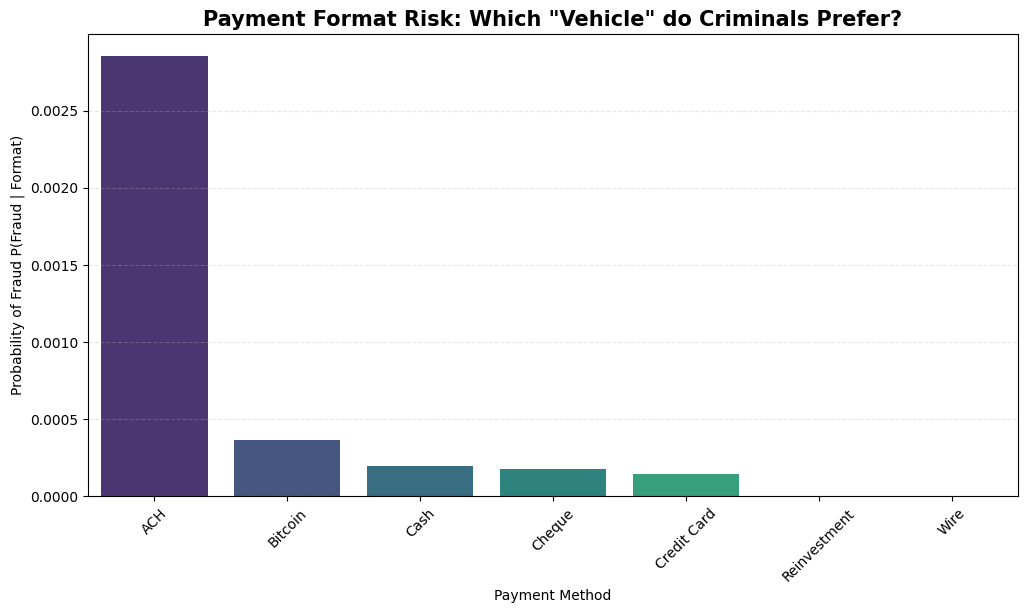

In [19]:
eda_format = x.iloc[:train_idx].copy()

# 2. Calculating both the Fraud Rate and the Total Volume per format
# We need both to ensure we aren't looking at a rare format with a lucky guess
format_stats = eda_format.groupby('Payment Format', observed=False)['Is Laundering'].agg(['mean', 'count']).sort_values(by='mean', ascending=False)
format_stats.columns = ['fraud_rate', 'total_volume']

plt.figure(figsize=(12, 6))
sns.barplot(x=format_stats.index, y=format_stats['fraud_rate'], palette='viridis')

plt.title('Payment Format Risk: Which "Vehicle" do Criminals Prefer?', fontsize=15, fontweight='bold')
plt.ylabel('Probability of Fraud P(Fraud | Format)')
plt.xlabel('Payment Method')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

In [20]:
#as per the data generated by the simulator
'''ACH is traditionally used for "safe" transactions like payroll and recurring bill payments.
The Criminal Strategy: Because ACH is often viewed as "boring" or "low-risk" by traditional bank filters
illicit actors are likely using it as a Trojan Horse
By exploiting the trust associated with ACH
they can move funds between accounts with less immediate scrutiny than a high-priority Wire transfer that is mostly used by corporates for big payments.
'''

'ACH is traditionally used for "safe" transactions like payroll and recurring bill payments.\nThe Criminal Strategy: Because ACH is often viewed as "boring" or "low-risk" by traditional bank filters\nillicit actors are likely using it as a Trojan Horse\nBy exploiting the trust associated with ACH\nthey can move funds between accounts with less immediate scrutiny than a high-priority Wire transfer that is mostly used by corporates for big payments.\n'

/tmp/ipykernel_1691/4002715560.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=significant_paths['fraud_rate'], y=significant_paths.index, palette='flare')


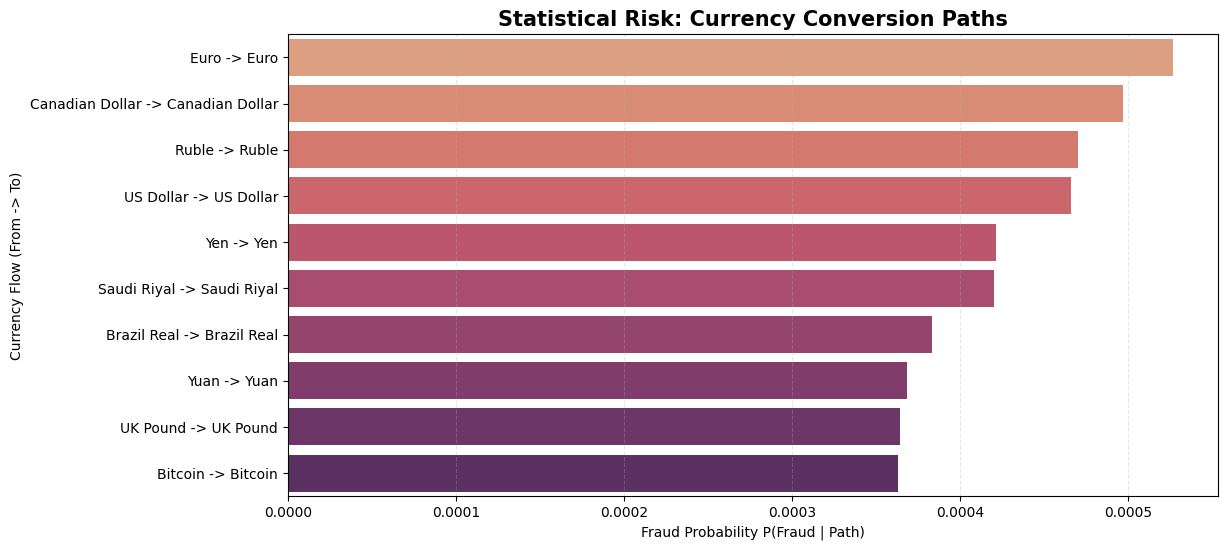

Risk Multiplier: 0.00x


In [23]:

# 1. Create a safe temporary copy
eda_curr = x.iloc[:train_idx].copy()

# Exact names from your check (with spaces)
pay_col = 'Payment Currency'
recv_col = 'Receiving Currency'

# 2. Identify the "Conversion" Flag 
# This handles the spaces and identifies cross-currency moves
eda_curr['is_conversion'] = (eda_curr[pay_col].astype(str).str.strip() != 
                             eda_curr[recv_col].astype(str).str.strip()).astype(int)

# 3. Create a 'Flow' column for visualization
eda_curr['Currency_Path'] = eda_curr[pay_col].astype(str) + " -> " + eda_curr[recv_col].astype(str)

# 4. Calculate Risk for significant paths
path_stats = eda_curr.groupby('Currency_Path', observed=False)['Is Laundering'].agg(['mean', 'count'])
path_stats.columns = ['fraud_rate', 'total_volume']

# Filter: Only show paths with a decent volume to avoid outliers
significant_paths = path_stats[path_stats['total_volume'] > 50].sort_values(by='fraud_rate', ascending=False).head(10)

# 5. Visualize
plt.figure(figsize=(12, 6))
sns.barplot(x=significant_paths['fraud_rate'], y=significant_paths.index, palette='flare')

plt.title('Statistical Risk: Currency Conversion Paths', fontsize=15, fontweight='bold')
plt.xlabel('Fraud Probability P(Fraud | Path)')
plt.ylabel('Currency Flow (From -> To)')
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.show()

# 6. The "Golden" Metric for your report
conv_risk = eda_curr.groupby('is_conversion')['Is Laundering'].mean()
print(f"Risk Multiplier: {conv_risk[1]/conv_risk[0]:.2f}x")

In [24]:
'''
This plot clearly shows that inter currency laundering is minimal as comapred to intra currency laundering.
Mules are intentionally doing intra currency laundering to prevent getting flagged
'''

'\nThis plot clearly shows that inter currency laundering is minimal as comapred to intra currency laundering.\nMules are intentionally doing intra currency laundering to prevent getting flagged\n'

/tmp/ipykernel_1691/1321535591.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mule_hubs['fraud_rate'], y=mule_hubs.index.astype(str), palette='YlOrRd_r')


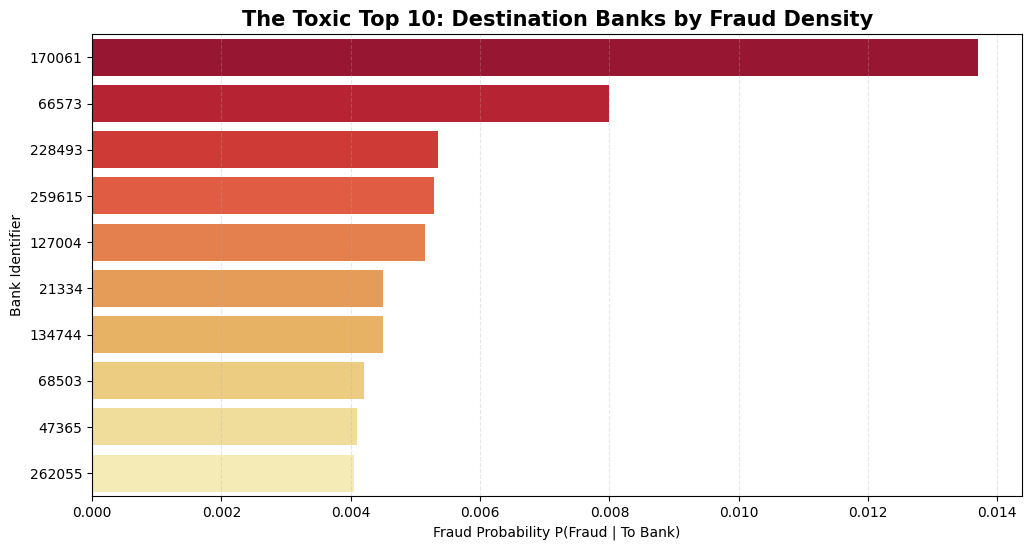

High-Risk Bank IDs: [170061, 66573, 228493, 259615, 127004, 21334, 134744, 68503, 47365, 262055]


In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Create a safe temporary copy
eda_banks = df.copy() # Using your preferred 'df' naming

# 2. Group by the destination 'To Bank' to see where fraud is accumulating
# This identifies the "Receiving Hubs"
bank_risk = eda_banks.groupby('To Bank', observed=False)['Is Laundering'].agg(['mean', 'count'])
bank_risk.columns = ['fraud_rate', 'total_volume']

# 3. Filter for banks with enough volume to be statistically relevant
# We want the 'High Density' hubs
mule_hubs = bank_risk[bank_risk['total_volume'] > 100].sort_values(by='fraud_rate', ascending=False).head(10)

# 4. Visualization
plt.figure(figsize=(12, 6))
sns.barplot(x=mule_hubs['fraud_rate'], y=mule_hubs.index.astype(str), palette='YlOrRd_r')

plt.title('The Toxic Top 10: Destination Banks by Fraud Density', fontsize=15, fontweight='bold')
plt.xlabel('Fraud Probability P(Fraud | To Bank)')
plt.ylabel('Bank Identifier')
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.show()

# Export list for Hop Analysis
high_risk_banks = mule_hubs.index.tolist()
print(f"High-Risk Bank IDs: {high_risk_banks}")

In [28]:
'''
The data reveals heavy risk clustering at specific institutions with Bank ID 170061 showing a fraud density nearly 3x higher than the rest of the top 10.
This concentration identifies these IDs as primary Mule Hubs, likely used by laundering networks as centralized "landing zones" to aggregate illicit funds before moving them into the layering phase.
'''

'\nThe data reveals heavy risk clustering at specific institutions with Bank ID 170061 showing a fraud density nearly 3x higher than the rest of the top 10.\nThis concentration identifies these IDs as primary Mule Hubs, likely used by laundering networks as centralized "landing zones" to aggregate illicit funds before moving them into the layering phase.\n'

External transfers are 11.92x riskier than internal transfers.


/tmp/ipykernel_1691/3720116985.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=hop_labels, y=hop_risk.values, palette='coolwarm')


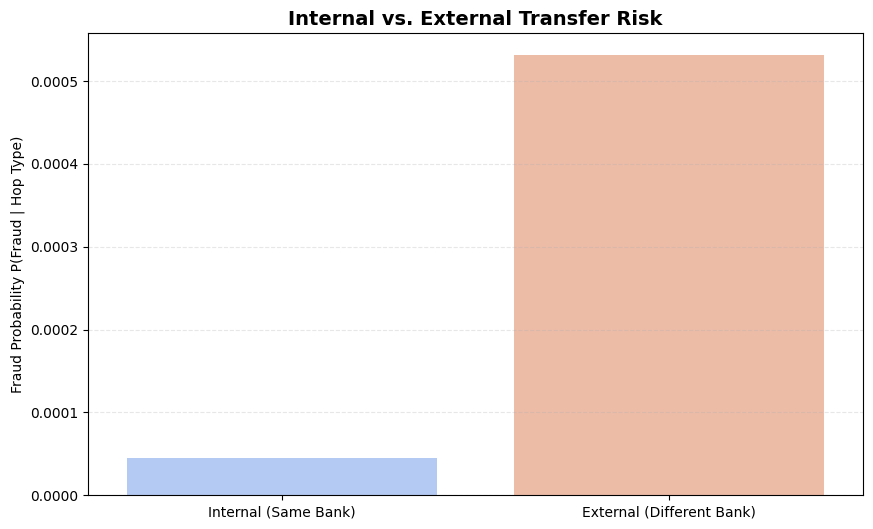

In [29]:
eda_hops = df.copy()

# 2. Define the 'Internal vs External' feature
# 1 if the banks are different, 0 if it's an internal transfer within the same bank
eda_hops['is_external_hop'] = (eda_hops['From Bank'] != eda_hops['To Bank']).astype(int)

# 3. Calculate Risk
hop_risk = eda_hops.groupby('is_external_hop', observed=False)['Is Laundering'].mean()
hop_labels = ['Internal (Same Bank)', 'External (Different Bank)']

# 4. Visualization
plt.figure(figsize=(10, 6))
sns.barplot(x=hop_labels, y=hop_risk.values, palette='coolwarm')

plt.title('Internal vs. External Transfer Risk', fontsize=14, fontweight='bold')
plt.ylabel('Fraud Probability P(Fraud | Hop Type)')
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Print the Risk Multiplier
multiplier = hop_risk[1] / hop_risk[0] if hop_risk[0] > 0 else 0
print(f"External transfers are {multiplier:.2f}x riskier than internal transfers.")
plt.show()

In [30]:
'''
Laundering is mostly done by passing the money through different banks
'''

'\nLaundering is mostly done by passing the money through different banks\n'